In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the dataset

df = pd.read_csv(r"C:\Smart Inventory Management System\data\sales_data.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 76000
Columns: 16


In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [5]:
#Missing values
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [6]:
#Duplicate records
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
df.dtypes

Date                      str
Store ID                  str
Product ID                str
Category                  str
Region                    str
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition         str
Promotion               int64
Competitor Pricing    float64
Seasonality               str
Epidemic                int64
Demand                  int64
dtype: object

In [8]:
print(df.dtypes.to_string())

Date                      str
Store ID                  str
Product ID                str
Category                  str
Region                    str
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition         str
Promotion               int64
Competitor Pricing    float64
Seasonality               str
Epidemic                int64
Demand                  int64


In [10]:
#datatype conversion
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [11]:
print(df.dtypes)

Date                  datetime64[us]
Store ID                         str
Product ID                       str
Category                         str
Region                           str
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition                str
Promotion                      int64
Competitor Pricing           float64
Seasonality                      str
Epidemic                       int64
Demand                         int64
dtype: object


In [12]:
print("Invalid dates:", df["Date"].isna().sum())

Invalid dates: 0


In [13]:
#Validate numerical columns

numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",
    "Demand"
]

df[numeric_cols].describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [14]:
#Check categorical columns
categorical_cols = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print("Unique values:", df[col].nunique())
    print(df[col].unique())


Store ID:
Unique values: 5
<ArrowStringArray>
['S001', 'S002', 'S003', 'S004', 'S005']
Length: 5, dtype: str

Product ID:
Unique values: 20
<ArrowStringArray>
['P0001', 'P0002', 'P0003', 'P0004', 'P0005', 'P0006', 'P0007', 'P0008',
 'P0009', 'P0010', 'P0011', 'P0012', 'P0013', 'P0014', 'P0015', 'P0016',
 'P0017', 'P0018', 'P0019', 'P0020']
Length: 20, dtype: str

Category:
Unique values: 5
<ArrowStringArray>
['Electronics', 'Clothing', 'Groceries', 'Toys', 'Furniture']
Length: 5, dtype: str

Region:
Unique values: 4
<ArrowStringArray>
['North', 'South', 'East', 'West']
Length: 4, dtype: str

Weather Condition:
Unique values: 4
<ArrowStringArray>
['Snowy', 'Cloudy', 'Sunny', 'Rainy']
Length: 4, dtype: str

Seasonality:
Unique values: 4
<ArrowStringArray>
['Winter', 'Spring', 'Summer', 'Autumn']
Length: 4, dtype: str


In [15]:
#Check the date range
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())
print("Total Days:", df["Date"].nunique())


Start Date: 2022-01-01 00:00:00
End Date: 2024-01-30 00:00:00
Total Days: 760


In [16]:
#Create time-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month Name"] = df["Date"].dt.month_name()
df["Year-Month"] = df["Date"].dt.to_period("M")

df[["Date", "Year", "Month", "Month Name", "Year-Month"]].head()


,Date,Year,Month,Month Name,Year-Month
0,2022-01-01,2022,1,January,2022-01
1,2022-01-01,2022,1,January,2022-01
2,2022-01-01,2022,1,January,2022-01
3,2022-01-01,2022,1,January,2022-01
4,2022-01-01,2022,1,January,2022-01


In [17]:
#Check inventory-related values
print("Inventory Level = 0:", (df["Inventory Level"] == 0).sum())
print("Inventory Level > 0:", (df["Inventory Level"] > 0).sum())

print("\nInventory statistics:")
print(df["Inventory Level"].describe())

Inventory Level = 0: 406
Inventory Level > 0: 75594

Inventory statistics:
count    76000.000000
mean       301.062842
std        226.510161
min          0.000000
25%        136.000000
50%        227.000000
75%        408.000000
max       2267.000000
Name: Inventory Level, dtype: float64


In [18]:
#Check the relationship between stock and demand
inventory_demand = df[["Inventory Level", "Units Sold", "Units Ordered", "Demand"]]

inventory_demand.describe()

,Inventory Level,Units Sold,Units Ordered,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,104.317158
std,226.510161,43.994525,162.404627,46.964801
min,0.000000,0.000000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,133.000000
max,2267.000000,426.000000,1616.000000,430.000000


In [19]:
#Calculate stock coverage
df["Stock_Coverage"] = df["Inventory Level"] / df["Demand"]

In [20]:
df["Stock_Coverage"].describe()

count    76000.000000
mean         3.667701
std          4.680114
min          0.000000
25%          1.378335
50%          2.501351
75%          4.538064
max        317.500000
Name: Stock_Coverage, dtype: float64

In [21]:
#Create the Stock Status

df["Stock Status"] = "Healthy Stock"

df.loc[df["Stock_Coverage"] < 1, "Stock Status"] = "Low Stock"
df.loc[df["Inventory Level"] == 0, "Stock Status"] = "Out of Stock"

In [22]:
print(df["Stock Status"].value_counts())

Stock Status
Healthy Stock    65606
Low Stock         9988
Out of Stock       406
Name: count, dtype: int64


In [23]:
#Calculate Inventory Value
df["Inventory Value"] = df["Inventory Level"] * df["Price"]
df["Inventory Value"].describe()

count     76000.000000
mean      20062.687474
std       19240.872634
min           0.000000
25%        6411.230000
50%       13630.495000
75%       27691.800000
max      229845.560000
Name: Inventory Value, dtype: float64

In [24]:
#Total Inventory Value
total_inventory_value = df["Inventory Value"].sum()
print(f"Total Inventory Value: {total_inventory_value:,.2f}")

Total Inventory Value: 1,524,764,248.00


In [25]:
#Category-wise inventory analysis
category_inventory = (
    df.groupby("Category")["Inventory Level"]
    .sum()
    .sort_values(ascending=False)
)

category_inventory


Category
Groceries      10953569
Clothing        3430379
Furniture       3421024
Electronics     2638055
Toys            2437749
Name: Inventory Level, dtype: int64

In [26]:
#Category-wise Inventory Value

category_value = (
    df.groupby("Category")["Inventory Value"]
    .sum()
    .sort_values(ascending=False)
)

category_value

Category
Groceries      5.698216e+08
Furniture      4.163970e+08
Clothing       2.532400e+08
Electronics    2.198123e+08
Toys           6.549326e+07
Name: Inventory Value, dtype: float64

In [27]:
#Product-wise Sales Analysis
top_products = (
    df.groupby("Product ID")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product ID
P0007    379709
P0004    377627
P0009    376771
P0013    376717
P0002    359355
P0010    357299
P0001    356814
P0005    351765
P0006    344589
P0003    341531
Name: Units Sold, dtype: int64

In [28]:
#Find the slowest-selling products
slow_products = (
    df.groupby("Product ID")["Units Sold"]
    .sum()
    .sort_values(ascending=True)
)

slow_products

Product ID
P0020    277961
P0017    294918
P0012    296256
P0018    310597
P0019    313209
P0014    317397
P0008    323317
P0016    326718
P0011    332883
P0015    335443
P0003    341531
P0006    344589
P0005    351765
P0001    356814
P0010    357299
P0002    359355
P0013    376717
P0009    376771
P0004    377627
P0007    379709
Name: Units Sold, dtype: int64

In [29]:
#Product-wise inventory vs sales
product_analysis = (
    df.groupby("Product ID")
    .agg(
        Total_Inventory=("Inventory Level", "sum"),
        Total_Sales=("Units Sold", "sum"),
        Total_Demand=("Demand", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
)

product_analysis

,Total_Inventory,Total_Sales,Total_Demand
Product ID,,,
P0007,1774068,379709,437089
P0004,1217330,377627,438505
P0009,1034754,376771,450324
P0013,1454080,376717,440895
P0002,1086157,359355,425853
P0010,1180088,357299,422064
P0001,1260683,356814,416447
P0005,1493036,351765,408578
P0006,1075622,344589,409345


In [30]:
#Calculate Sell-Through Rat
product_analysis["Sell_Through_Rate"] = (
    product_analysis["Total_Sales"]
    / (product_analysis["Total_Sales"] + product_analysis["Total_Inventory"])
) * 100

product_analysis.sort_values(
    "Sell_Through_Rate",
    ascending=False
)

,Total_Inventory,Total_Sales,Total_Demand,Sell_Through_Rate
Product ID,,,,
P0008,575439,323317,396538,35.973835
P0018,706161,310597,377205,30.547780
P0019,807445,313209,371954,27.948769
P0009,1034754,376771,450324,26.692478
P0017,855660,294918,350620,25.632161
P0002,1086157,359355,425853,24.860050
P0006,1075622,344589,409345,24.263226
P0004,1217330,377627,438505,23.676312
P0010,1180088,357299,422064,23.240667


In [31]:
#Create movement categories
product_analysis["Movement"] = "Moderate Moving"

product_analysis.loc[
    product_analysis["Sell_Through_Rate"] >= 30,
    "Movement"
] = "Fast Moving"

product_analysis.loc[
    product_analysis["Sell_Through_Rate"] < 20,
    "Movement"
] = "Slow Moving"

product_analysis[["Total_Inventory", "Total_Sales", "Sell_Through_Rate", "Movement"]]

,Total_Inventory,Total_Sales,Sell_Through_Rate,Movement
Product ID,,,,
P0007,1774068,379709,17.629912,Slow Moving
P0004,1217330,377627,23.676312,Moderate Moving
P0009,1034754,376771,26.692478,Moderate Moving
P0013,1454080,376717,20.576667,Moderate Moving
P0002,1086157,359355,24.860050,Moderate Moving
P0010,1180088,357299,23.240667,Moderate Moving
P0001,1260683,356814,22.059639,Moderate Moving
P0005,1493036,351765,19.067910,Slow Moving
P0006,1075622,344589,24.263226,Moderate Moving


In [32]:
print(product_analysis["Movement"].value_counts())

Movement
Moderate Moving    15
Slow Moving         3
Fast Moving         2
Name: count, dtype: int64


In [33]:
#Monthly Inventory Trend 

monthly_inventory = (
    df.groupby("Year-Month")["Inventory Level"]
    .mean()
)

monthly_inventory


Year-Month
2022-01    299.272258
2022-02    322.022500
2022-03    323.283871
2022-04    311.067000
2022-05    236.835161
2022-06    325.022000
2022-07    268.661290
2022-08    329.760000
2022-09    305.864667
2022-10    299.438387
2022-11    309.411333
2022-12    313.656452
2023-01    323.132581
2023-02    237.053571
2023-03    304.193871
2023-04    276.501000
2023-05    270.204194
2023-06    328.587000
2023-07    332.316129
2023-08    339.526452
2023-09    304.679000
2023-10    268.807419
2023-11    297.673667
2023-12    311.602903
2024-01    284.934667
Freq: M, Name: Inventory Level, dtype: float64

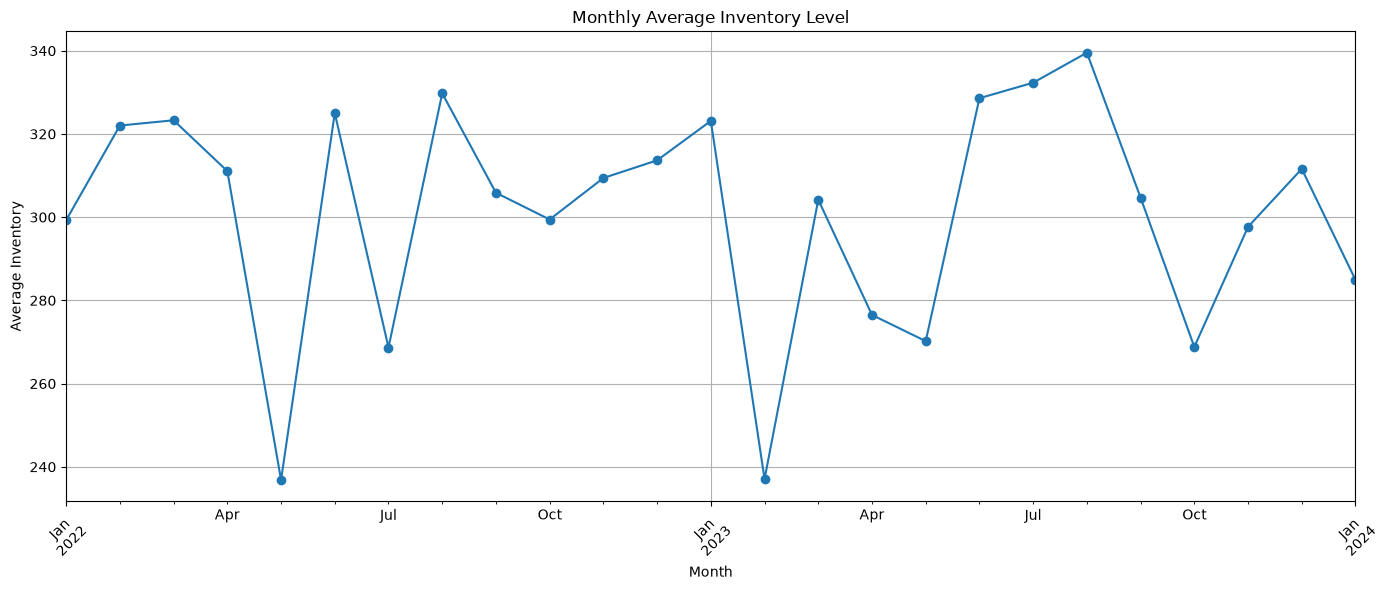

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

monthly_inventory.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Average Inventory Level")
plt.xlabel("Month")
plt.ylabel("Average Inventory")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
#Monthly Sales & Demand Trend

monthly_sales_demand = (
    df.groupby("Year-Month")[["Units Sold", "Demand"]]
    .sum()
)

monthly_sales_demand

,Units Sold,Demand
Year-Month,,
2022-01,283495,341544
2022-02,271108,319883
2022-03,303752,353173
2022-04,260812,305076
2022-05,205949,239112
2022-06,292816,345725
2022-07,220157,259736
2022-08,316705,370437
2022-09,277151,324264


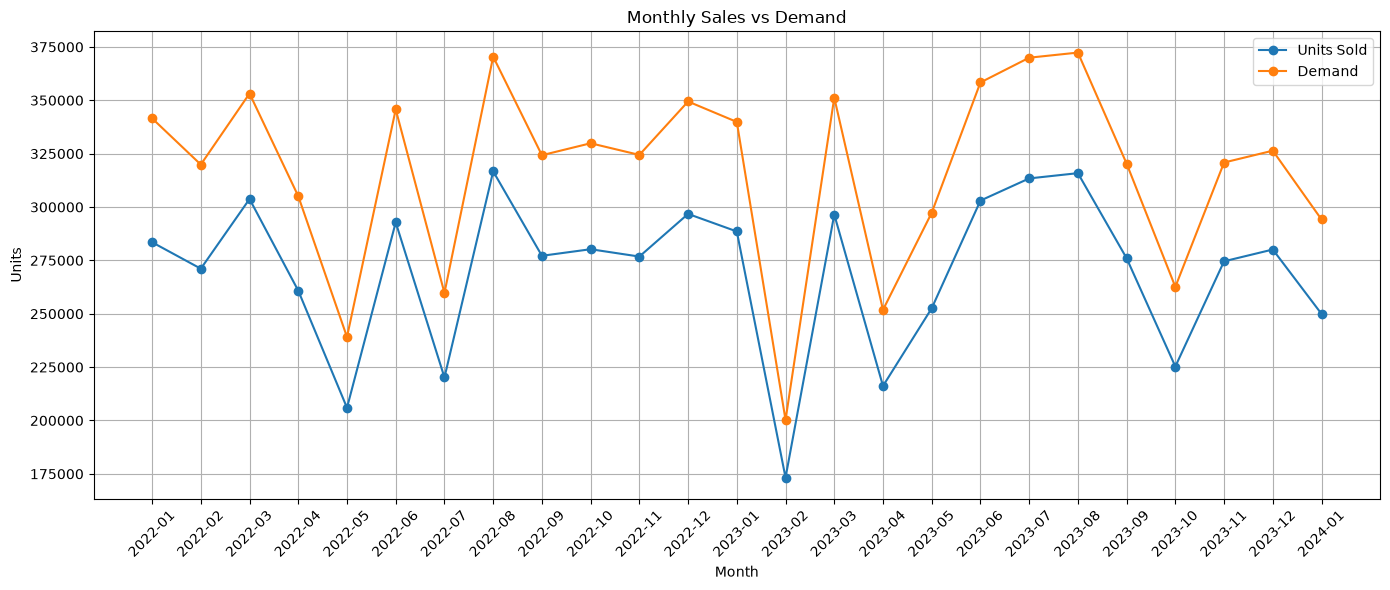

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales_demand.index.astype(str),
    monthly_sales_demand["Units Sold"],
    marker="o",
    label="Units Sold"
)

plt.plot(
    monthly_sales_demand.index.astype(str),
    monthly_sales_demand["Demand"],
    marker="o",
    label="Demand"
)

plt.title("Monthly Sales vs Demand")
plt.xlabel("Month")
plt.ylabel("Units")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
#Category-wise Sales & Demand
category_performance = (
    df.groupby("Category")[["Units Sold", "Demand"]]
    .sum()
    .sort_values("Units Sold", ascending=False)
)

category_performance


,Units Sold,Demand
Category,,
Groceries,3127335,3677684
Clothing,1150873,1369456
Furniture,880654,1006590
Toys,834679,985338
Electronics,757335,889036


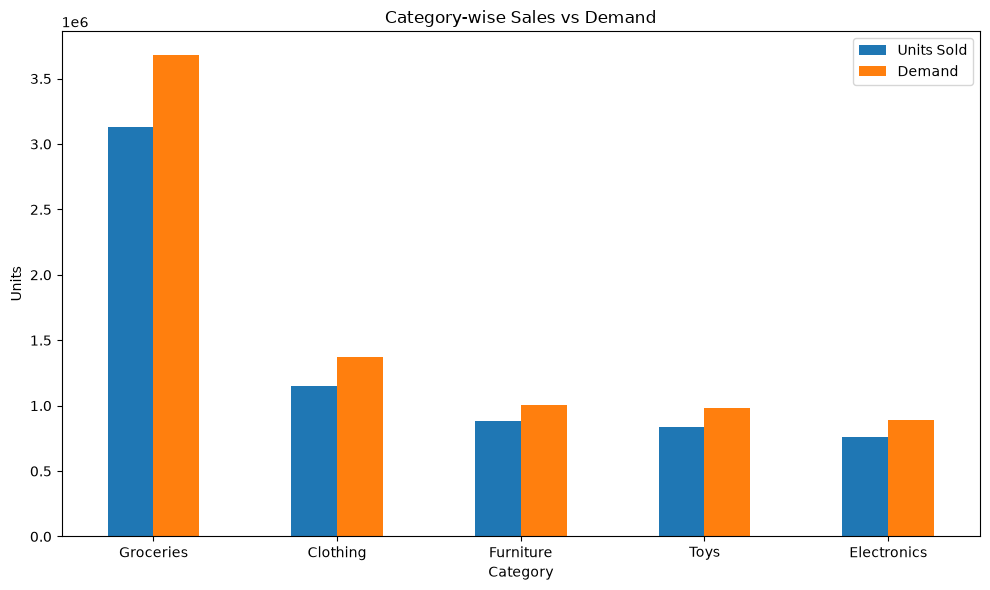

In [38]:
category_performance.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Category-wise Sales vs Demand")
plt.xlabel("Category")
plt.ylabel("Units")
plt.xticks(rotation=0)
plt.legend(["Units Sold", "Demand"])
plt.tight_layout()
plt.show()

In [39]:
#Store/Region Analysis
store_analysis = (
    df.groupby("Store ID")[["Inventory Level", "Units Sold", "Demand"]]
    .sum()
    .sort_values("Inventory Level", ascending=False)
)

store_analysis

,Inventory Level,Units Sold,Demand
Store ID,,,
S002,5046624,1386126,1625471
S003,4894294,1375613,1618324
S004,4457312,1308191,1529651
S005,4262154,1362812,1607085
S001,4220392,1318134,1547573


In [40]:
region_analysis = (
    df.groupby("Region")[["Inventory Level", "Units Sold", "Demand"]]
    .sum()
    .sort_values("Inventory Level", ascending=False)
)

region_analysis

,Inventory Level,Units Sold,Demand
Region,,,
North,8482546,2680946,3154658
South,5046624,1386126,1625471
East,4894294,1375613,1618324
West,4457312,1308191,1529651


In [41]:
#Prepare the final inventory dataset
df["Reorder Level"] = df["Demand"] * 1.2
df["Reorder Level"] = df["Reorder Level"].round().astype(int)

df[[
    "Product ID",
    "Inventory Level",
    "Demand",
    "Reorder Level",
    "Stock Status"
]].head(10)

,Product ID,Inventory Level,Demand,Reorder Level,Stock Status
0,P0001,195,115,138,Healthy Stock
1,P0002,117,229,275,Low Stock
2,P0003,247,157,188,Healthy Stock
3,P0004,139,52,62,Healthy Stock
4,P0005,152,59,71,Healthy Stock
5,P0006,209,55,66,Healthy Stock
6,P0007,118,94,113,Healthy Stock
7,P0008,244,61,73,Healthy Stock
8,P0009,115,129,155,Low Stock
9,P0010,192,69,83,Healthy Stock


In [42]:
df["Reorder Quantity"] = (
    df["Reorder Level"] - df["Inventory Level"]
).clip(lower=0)

df[[
    "Product ID",
    "Inventory Level",
    "Demand",
    "Reorder Level",
    "Reorder Quantity",
    "Stock Status"
]].head(10)

,Product ID,Inventory Level,Demand,Reorder Level,Reorder Quantity,Stock Status
0,P0001,195,115,138,0,Healthy Stock
1,P0002,117,229,275,158,Low Stock
2,P0003,247,157,188,0,Healthy Stock
3,P0004,139,52,62,0,Healthy Stock
4,P0005,152,59,71,0,Healthy Stock
5,P0006,209,55,66,0,Healthy Stock
6,P0007,118,94,113,0,Healthy Stock
7,P0008,244,61,73,0,Healthy Stock
8,P0009,115,129,155,40,Low Stock
9,P0010,192,69,83,0,Healthy Stock


In [43]:
print("Products requiring reorder:",
      (df["Reorder Quantity"] > 0).sum())

Products requiring reorder: 14850


In [44]:
# Convert Year-Month to text before exporting
df["Year-Month"] = df["Year-Month"].astype(str)

# Save processed inventory dataset
output_path = r"C:\Smart Inventory Management System\data\inventory_data.csv"

df.to_csv(output_path, index=False)

print("Processed inventory dataset saved successfully!")
print("File:", output_path)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Processed inventory dataset saved successfully!
File: C:\Smart Inventory Management System\data\inventory_data.csv
Rows: 76000
Columns: 25


In [45]:
print("Total columns:", len(df.columns))
print("\nFinal columns:")
print(df.columns.tolist())

Total columns: 25

Final columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand', 'Year', 'Month', 'Month Name', 'Year-Month', 'Stock_Coverage', 'Stock Status', 'Inventory Value', 'Reorder Level', 'Reorder Quantity']


In [46]:
monthly_demand = (
    df.groupby("Year-Month")["Demand"]
    .sum()
    .reset_index()
)

monthly_demand

,Year-Month,Demand
0,2022-01,341544
1,2022-02,319883
2,2022-03,353173
3,2022-04,305076
4,2022-05,239112
5,2022-06,345725
6,2022-07,259736
7,2022-08,370437
8,2022-09,324264
9,2022-10,329865


In [47]:
monthly_demand["Moving_Average_3M"] = (
    monthly_demand["Demand"]
    .rolling(window=3)
    .mean()
)

monthly_demand

,Year-Month,Demand,Moving_Average_3M
0,2022-01,341544,NaN
1,2022-02,319883,NaN
2,2022-03,353173,338200.000000
3,2022-04,305076,326044.000000
4,2022-05,239112,299120.333333
5,2022-06,345725,296637.666667
6,2022-07,259736,281524.333333
7,2022-08,370437,325299.333333
8,2022-09,324264,318145.666667
9,2022-10,329865,341522.000000


In [48]:
latest_3_months = monthly_demand["Demand"].tail(3)

next_month_forecast = latest_3_months.mean()

print("Latest 3 Months Demand:")
print(latest_3_months)

print(f"\nNext Month Demand Forecast: {next_month_forecast:.0f} units")

Latest 3 Months Demand:
22    320848
23    326389
24    294159
Name: Demand, dtype: int64

Next Month Demand Forecast: 313799 units


In [49]:
forecast_result = pd.DataFrame({
    "Forecast Period": ["2024-02"],
    "Forecast Method": ["3-Month Moving Average"],
    "Forecast Demand": [round(next_month_forecast)]
})

forecast_result

,Forecast Period,Forecast Method,Forecast Demand
0,2024-02,3-Month Moving Average,313799


In [50]:
forecast_path = r"C:\Smart Inventory Management System\data\demand_forecast.csv"

forecast_result.to_csv(forecast_path, index=False)

print("Forecast saved successfully!")
print("File:", forecast_path)

Forecast saved successfully!
File: C:\Smart Inventory Management System\data\demand_forecast.csv


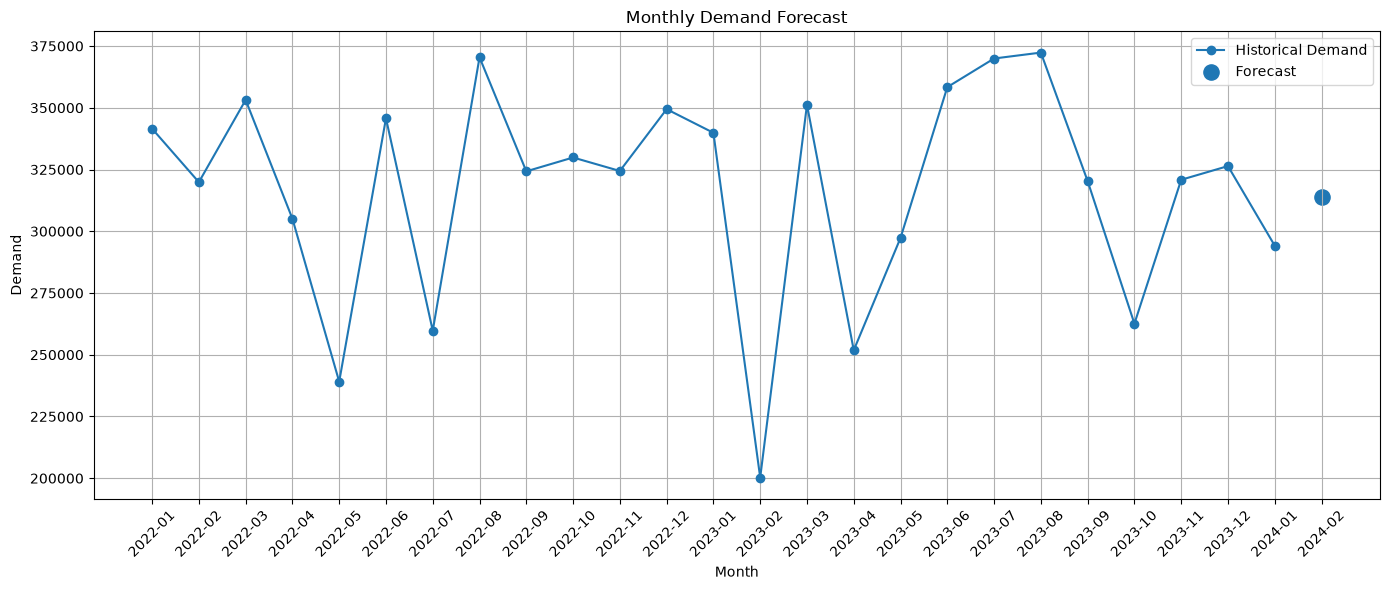

In [51]:
forecast_plot = monthly_demand.copy()

forecast_plot["Year-Month"] = forecast_plot["Year-Month"].astype(str)

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_plot["Year-Month"],
    forecast_plot["Demand"],
    marker="o",
    label="Historical Demand"
)

plt.scatter(
    ["2024-02"],
    [next_month_forecast],
    s=120,
    label="Forecast"
)

plt.title("Monthly Demand Forecast")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
df["Recommendation"] = "No Action"

df.loc[
    df["Stock Status"] == "Out of Stock",
    "Recommendation"
] = "Urgent Restock"

df.loc[
    (df["Stock Status"] == "Low Stock") &
    (df["Reorder Quantity"] > 0),
    "Recommendation"
] = "Restock Soon"

In [53]:
print(df["Recommendation"].value_counts())

Recommendation
No Action         65606
Restock Soon       9988
Urgent Restock      406
Name: count, dtype: int64


In [54]:
#Overstock Detection
df["Inventory Condition"] = "Normal"
df.loc[
    df["Stock_Coverage"] >= 6,
    "Inventory Condition"
] = "Overstocked"

print(df["Inventory Condition"].value_counts())

Inventory Condition
Normal         64227
Overstocked    11773
Name: count, dtype: int64


In [55]:
#Final Smart Recommendation

df["Smart Recommendation"] = "No Action"

# Out of stock → urgent restock
df.loc[
    df["Stock Status"] == "Out of Stock",
    "Smart Recommendation"
] = "Urgent Restock"

# Low stock → restock soon
df.loc[
    (df["Stock Status"] == "Low Stock") &
    (df["Reorder Quantity"] > 0),
    "Smart Recommendation"
] = "Restock Soon"

# Overstocked → reduce / monitor stock
df.loc[
    (df["Inventory Condition"] == "Overstocked") &
    (df["Stock Status"] == "Healthy Stock"),
    "Smart Recommendation"
] = "Overstock - Monitor"

print(df["Smart Recommendation"].value_counts())

Smart Recommendation
No Action              53833
Overstock - Monitor    11773
Restock Soon            9988
Urgent Restock           406
Name: count, dtype: int64


In [56]:
# Prepare monthly demand data for forecasting models

forecast_data = monthly_demand[["Year-Month", "Demand"]].copy()

# Convert Year-Month to datetime
forecast_data["Date"] = pd.to_datetime(
    forecast_data["Year-Month"]
)

# Create time index
forecast_data["Time_Index"] = range(len(forecast_data))

forecast_data

,Year-Month,Demand,Date,Time_Index
0,2022-01,341544,2022-01-01,0
1,2022-02,319883,2022-02-01,1
2,2022-03,353173,2022-03-01,2
3,2022-04,305076,2022-04-01,3
4,2022-05,239112,2022-05-01,4
5,2022-06,345725,2022-06-01,5
6,2022-07,259736,2022-07-01,6
7,2022-08,370437,2022-08-01,7
8,2022-09,324264,2022-09-01,8
9,2022-10,329865,2022-10-01,9


In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Training and testing data
train = forecast_data.iloc[:-5]
test = forecast_data.iloc[-5:]

# Feature and target
X_train = train[["Time_Index"]]
y_train = train["Demand"]

X_test = test[["Time_Index"]]
y_test = test["Demand"]

# Train Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predictions
linear_predictions = linear_model.predict(X_test)

# Evaluation
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print(f"MAE  : {linear_mae:.2f}")
print(f"RMSE : {linear_rmse:.2f}")
print(f"R²   : {linear_r2:.4f}")

Linear Regression Results
MAE  : 25697.25
RMSE : 35068.92
R²   : -1.1504


In [58]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Results
MAE  : 61494.45
RMSE : 65980.87
R²   : -6.6122


In [60]:
from statsmodels.tsa.arima.model import ARIMA

# Training and testing demand
train_demand = forecast_data["Demand"].iloc[:-5]
test_demand = forecast_data["Demand"].iloc[-5:]

# Train ARIMA model
arima_model = ARIMA(
    train_demand,
    order=(1, 1, 1)
)

arima_fitted = arima_model.fit()

# Forecast the same 5-month test period
arima_predictions = arima_fitted.forecast(
    steps=len(test_demand)
)

# Evaluation
arima_mae = mean_absolute_error(
    test_demand,
    arima_predictions
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test_demand,
        arima_predictions
    )
)

arima_r2 = r2_score(
    test_demand,
    arima_predictions
)

print("ARIMA Results")
print(f"MAE  : {arima_mae:.2f}")
print(f"RMSE : {arima_rmse:.2f}")
print(f"R²   : {arima_r2:.4f}")

ARIMA Results
MAE  : 66949.90
RMSE : 71109.52
R²   : -7.8416


In [61]:
# 3-month moving average predictions for the test period

moving_average_predictions = (
    forecast_data["Demand"]
    .rolling(window=3)
    .mean()
    .iloc[-5:]
)

# Actual test values
moving_average_actual = forecast_data["Demand"].iloc[-5:]

# Remove any missing values
valid = ~moving_average_predictions.isna()

moving_average_predictions = moving_average_predictions[valid]
moving_average_actual = moving_average_actual[valid]

# Evaluation
ma_mae = mean_absolute_error(
    moving_average_actual,
    moving_average_predictions
)

ma_rmse = np.sqrt(
    mean_squared_error(
        moving_average_actual,
        moving_average_predictions
    )
)

ma_r2 = r2_score(
    moving_average_actual,
    moving_average_predictions
)

print("Moving Average Results")
print(f"MAE  : {ma_mae:.2f}")
print(f"RMSE : {ma_rmse:.2f}")
print(f"R²   : {ma_r2:.4f}")

Moving Average Results
MAE  : 30411.27
RMSE : 33372.63
R²   : -0.9474


In [62]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "ARIMA",
        "Moving Average"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        arima_mae,
        ma_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        arima_rmse,
        ma_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        arima_r2,
        ma_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,25697.252632,35068.917480,-1.150393
1,Random Forest,61494.445000,65980.873465,-6.612184
2,ARIMA,66949.902301,71109.515200,-7.841554
3,Moving Average,30411.266667,33372.625123,-0.947394


In [63]:
# Save forecasting model comparison

comparison_path = r"C:\Smart Inventory Management System\data\forecast_model_comparison.csv"

model_comparison.to_csv(comparison_path, index=False)

print("Model comparison saved successfully!")
print("File:", comparison_path)

Model comparison saved successfully!
File: C:\Smart Inventory Management System\data\forecast_model_comparison.csv


In [64]:
model_comparison.round(2)

,Model,MAE,RMSE,R2
0,Linear Regression,25697.25,35068.92,-1.15
1,Random Forest,61494.45,65980.87,-6.61
2,ARIMA,66949.90,71109.52,-7.84
3,Moving Average,30411.27,33372.63,-0.95


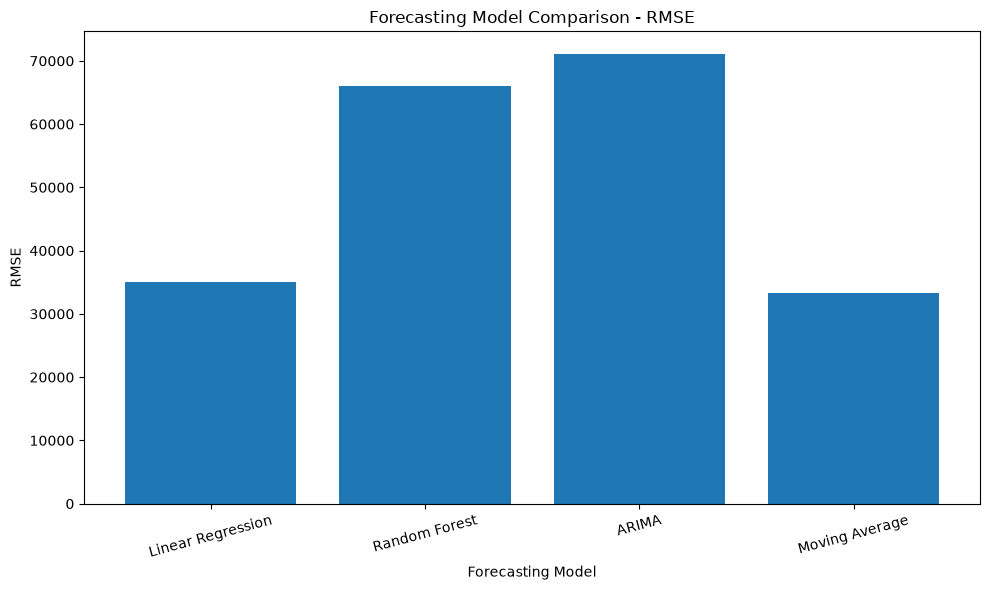

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

plt.title("Forecasting Model Comparison - RMSE")
plt.xlabel("Forecasting Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

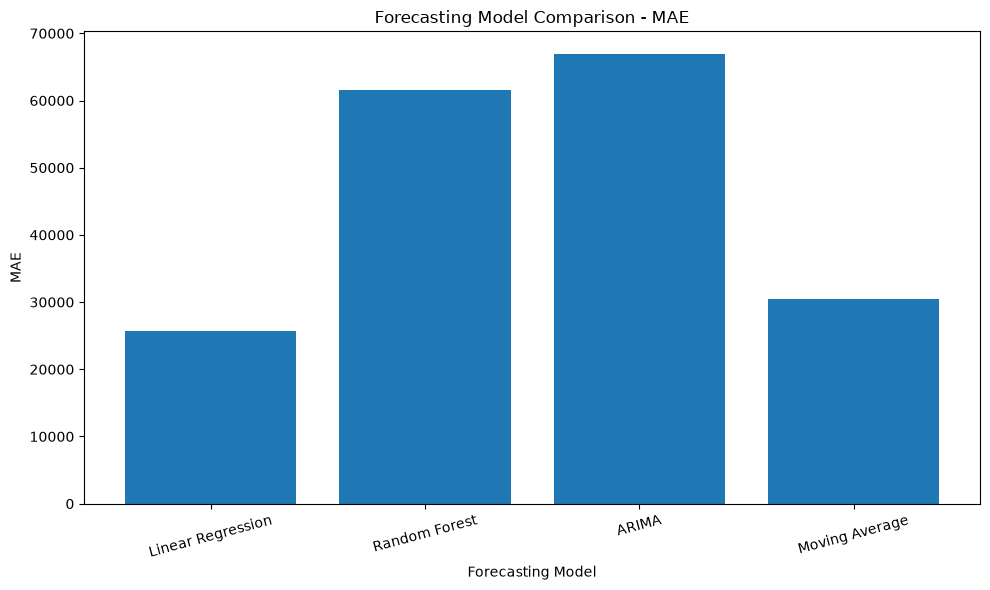

In [66]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

plt.title("Forecasting Model Comparison - MAE")
plt.xlabel("Forecasting Model")
plt.ylabel("MAE")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [67]:
# Final demand forecast

final_forecast = pd.DataFrame({
    "Forecast Period": ["2024-02"],
    "Forecast Method": ["3-Month Moving Average"],
    "Forecast Demand": [round(next_month_forecast)]
})

final_forecast

,Forecast Period,Forecast Method,Forecast Demand
0,2024-02,3-Month Moving Average,313799


In [68]:
forecast_path = r"C:\Smart Inventory Management System\data\demand_forecast.csv"

final_forecast.to_csv(forecast_path, index=False)

print("Final forecast saved successfully!")
print("File:", forecast_path)

Final forecast saved successfully!
File: C:\Smart Inventory Management System\data\demand_forecast.csv


In [69]:
# Final inventory classification

df["Inventory Condition"] = "Normal"

df.loc[
    df["Stock_Coverage"] >= 6,
    "Inventory Condition"
] = "Overstocked"


# Smart recommendations

df["Smart Recommendation"] = "No Action"

df.loc[
    df["Stock Status"] == "Out of Stock",
    "Smart Recommendation"
] = "Urgent Restock"

df.loc[
    (df["Stock Status"] == "Low Stock") &
    (df["Reorder Quantity"] > 0),
    "Smart Recommendation"
] = "Restock Soon"

df.loc[
    (df["Inventory Condition"] == "Overstocked") &
    (df["Stock Status"] == "Healthy Stock"),
    "Smart Recommendation"
] = "Overstock - Monitor"


# Save final processed dataset

output_path = r"C:\Smart Inventory Management System\data\inventory_data.csv"

df.to_csv(
    output_path,
    index=False
)

print("Final inventory dataset saved successfully.")
print("Shape:", df.shape)

print("\nInventory Condition:")
print(df["Inventory Condition"].value_counts())

print("\nSmart Recommendation:")
print(df["Smart Recommendation"].value_counts())

Final inventory dataset saved successfully.
Shape: (76000, 28)

Inventory Condition:
Inventory Condition
Normal         64227
Overstocked    11773
Name: count, dtype: int64

Smart Recommendation:
Smart Recommendation
No Action              53833
Overstock - Monitor    11773
Restock Soon            9988
Urgent Restock           406
Name: count, dtype: int64
